**© Copyright AIDENTIFY. All rights reserved.**

In [23]:
import platform
import matplotlib.pyplot as plt

# OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumBarunGothic') # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

# Part 1 | Session 01: 자연어 처리 기초 - 인코딩, 토큰화, 임베딩(Word2Vec)

---

이 노트북에서는 자연어 처리(NLP)의 기초가 되는 핵심 개념들을 학습합니다:

1. **텍스트 인코딩**: 컴퓨터가 문자를 이해하는 방법 (ASCII, UTF-8, Unicode)
2. **토큰화(Tokenization)**: 텍스트를 의미 단위로 분리하는 방법
3. **임베딩(Embedding)**: 단어를 벡터 공간에 표현하는 방법 (Word2Vec)
4. **현대 임베딩**: 문맥 기반 임베딩 간단 소개
5. **실습**: 한국어 텍스트로 직접 실습

## 환경 설정

필요한 패키지를 설치합니다.

In [1]:
# 💡 setup.sh 실행했으면 이 셀은 건너뛰세요 (참고용 — 본 노트북이 필요로 하는 패키지)
# !pip install -q transformers tokenizers gensim matplotlib scikit-learn numpy

---
## 1️⃣ 텍스트 인코딩 (Text Encoding)

컴퓨터는 숫자만 이해할 수 있습니다. 그래서 문자를 숫자로 변환하는 **인코딩(encoding)** 과정이 필요합니다.

### 주요 인코딩 방식

| 인코딩 | 설명 | 범위 |
|---------|------|------|
| **ASCII** | 7비트, 128개 문자 | 영어 + 기본 기호만 |
| **Unicode** | 전 세계 모든 문자에 고유 코드 포인트 부여 | 한글, 이모지 등 모두 포함 |
| **UTF-8** | 가변 길이 인코딩 (1~4바이트) | Unicode의 실제 저장/전송 방식 |

> **핵심**: Unicode는 문자와 코드 포인트의 **매핑 테이블**이고, UTF-8은 그 코드 포인트를 **바이트로 저장하는 방법**입니다.

In [1]:
# === ASCII 인코딩 ===
text_en = "Hello"
print("=== ASCII 인코딩 ===")
for ch in text_en:
    print(f"  '{ch}' -> ASCII: {ord(ch)}, 이진수: {bin(ord(ch))}")

print()

# === 한글은 ASCII로 인코딩 불가 ===
text_ko = "한글"
try:
    text_ko.encode('ascii')
except UnicodeEncodeError as e:
    print(f"한글 ASCII 인코딩 실패: {e}")

=== ASCII 인코딩 ===
  'H' -> ASCII: 72, 이진수: 0b1001000
  'e' -> ASCII: 101, 이진수: 0b1100101
  'l' -> ASCII: 108, 이진수: 0b1101100
  'l' -> ASCII: 108, 이진수: 0b1101100
  'o' -> ASCII: 111, 이진수: 0b1101111

한글 ASCII 인코딩 실패: 'ascii' codec can't encode characters in position 0-1: ordinal not in range(128)


In [2]:
# === Unicode 코드 포인트 확인 ===
text = "한글 NLP 시작!"
print("=== Unicode 코드 포인트 ===")
for ch in text:
    print(f"  '{ch}' -> U+{ord(ch):04X} (10진수: {ord(ch)})")

print()

# === UTF-8 인코딩: 문자마다 바이트 수가 다름 ===
print("=== UTF-8 인코딩 (바이트 단위) ===")
for ch in text:
    encoded = ch.encode('utf-8')
    hex_str = ' '.join(f'{b:02x}' for b in encoded)
    print(f"  '{ch}' -> {len(encoded)}바이트: [{hex_str}]")

print(f"\n전체 문자열 UTF-8 바이트 수: {len(text.encode('utf-8'))} bytes")
print(f"전체 문자 수 (len): {len(text)} 문자")

=== Unicode 코드 포인트 ===
  '한' -> U+D55C (10진수: 54620)
  '글' -> U+AE00 (10진수: 44544)
  ' ' -> U+0020 (10진수: 32)
  'N' -> U+004E (10진수: 78)
  'L' -> U+004C (10진수: 76)
  'P' -> U+0050 (10진수: 80)
  ' ' -> U+0020 (10진수: 32)
  '시' -> U+C2DC (10진수: 49884)
  '작' -> U+C791 (10진수: 51089)
  '!' -> U+0021 (10진수: 33)

=== UTF-8 인코딩 (바이트 단위) ===
  '한' -> 3바이트: [ed 95 9c]
  '글' -> 3바이트: [ea b8 80]
  ' ' -> 1바이트: [20]
  'N' -> 1바이트: [4e]
  'L' -> 1바이트: [4c]
  'P' -> 1바이트: [50]
  ' ' -> 1바이트: [20]
  '시' -> 3바이트: [ec 8b 9c]
  '작' -> 3바이트: [ec 9e 91]
  '!' -> 1바이트: [21]

전체 문자열 UTF-8 바이트 수: 18 bytes
전체 문자 수 (len): 10 문자


> **포인트**: 한글 한 글자는 UTF-8에서 **3바이트**를 차지합니다. 영어는 1바이트입니다. 이 차이가 LLM의 토큰 효율성에도 영향을 미칩니다.

---
## 2️⃣ 토큰화 (Tokenization)

**토큰화**란 텍스트를 모델이 처리할 수 있는 최소 단위(**토큰**)로 분리하는 과정입니다.

### 토큰화 전략 비교

| 방식 | 설명 | 예시 |
|------|------|------|
| **단어 단위** (Word-level) | 공백/구두점 기준 분리 | `["나는", "학생이다"]` |
| **서브워드** (Subword) | 자주 나오는 부분 단어로 분리 | `["나", "는", "학생", "이다"]` |
| **문자 단위** (Character-level) | 글자 하나씩 분리 | `["나", "는", "학", "생", ...]` |

### 서브워드 토큰화 알고리즘

- **BPE (Byte Pair Encoding)**: 가장 빈번한 문자 쌍을 반복적으로 병합 (GPT 계열)
- **WordPiece**: BPE와 유사하지만 우도(likelihood) 기반 병합 (BERT)
- **SentencePiece**: 언어 독립적, 공백도 토큰으로 처리 (T5, LLaMA)

In [3]:
# === 1. 단어 단위 토큰화 (가장 단순한 방법) ===
text = "자연어 처리는 인공지능의 핵심 분야입니다."

# 공백 기준 분리
word_tokens = text.split()
print("[단어 단위 토큰화]")
print(f"  원문: {text}")
print(f"  토큰: {word_tokens}")
print(f"  토큰 수: {len(word_tokens)}")

print()

# === 2. 문자 단위 토큰화 ===
char_tokens = list(text.replace(' ', ''))
print("[문자 단위 토큰화]")
print(f"  토큰: {char_tokens}")
print(f"  토큰 수: {len(char_tokens)}")

[단어 단위 토큰화]
  원문: 자연어 처리는 인공지능의 핵심 분야입니다.
  토큰: ['자연어', '처리는', '인공지능의', '핵심', '분야입니다.']
  토큰 수: 5

[문자 단위 토큰화]
  토큰: ['자', '연', '어', '처', '리', '는', '인', '공', '지', '능', '의', '핵', '심', '분', '야', '입', '니', '다', '.']
  토큰 수: 19


In [4]:
# === 3. 서브워드 토큰화: HuggingFace Transformers 사용 ===
from transformers import AutoTokenizer

text = "자연어 처리는 인공지능의 핵심 분야입니다."

# --- BERT (WordPiece) ---
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
bert_tokens = bert_tokenizer.tokenize(text)
bert_ids = bert_tokenizer.encode(text)

print("=== BERT (WordPiece) ===")
print(f"  토큰: {bert_tokens}")
print(f"  토큰 ID: {bert_ids}")
print(f"  토큰 수: {len(bert_tokens)}")
print()

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

Could not set the permissions on the file '/workspace/.cache/huggingface/hub/models--bert-base-multilingual-cased/blobs/b122e74db13b415ea824c074da33c1c44f0d13a3.003c5361.incomplete'. Error: [Errno 1] Operation not permitted: '/workspace/.cache/huggingface/hub/models--bert-base-multilingual-cased/blobs/b122e74db13b415ea824c074da33c1c44f0d13a3.003c5361.incomplete'.
Continuing without setting permissions.


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

Could not set the permissions on the file '/workspace/.cache/huggingface/hub/models--bert-base-multilingual-cased/blobs/2ba5de7675473164e07f3b3531748c9a6f113a2c.8b518316.incomplete'. Error: [Errno 1] Operation not permitted: '/workspace/.cache/huggingface/hub/models--bert-base-multilingual-cased/blobs/2ba5de7675473164e07f3b3531748c9a6f113a2c.8b518316.incomplete'.
Continuing without setting permissions.


vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

Could not set the permissions on the file '/workspace/.cache/huggingface/hub/models--bert-base-multilingual-cased/blobs/e837bab60a5d204e29622d127c2dafe508aa0731.5d85c5d3.incomplete'. Error: [Errno 1] Operation not permitted: '/workspace/.cache/huggingface/hub/models--bert-base-multilingual-cased/blobs/e837bab60a5d204e29622d127c2dafe508aa0731.5d85c5d3.incomplete'.
Continuing without setting permissions.


tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Could not set the permissions on the file '/workspace/.cache/huggingface/hub/models--bert-base-multilingual-cased/blobs/420b0fc31334c64ddf53cc3e9222a6d4c59d0cae.3b365366.incomplete'. Error: [Errno 1] Operation not permitted: '/workspace/.cache/huggingface/hub/models--bert-base-multilingual-cased/blobs/420b0fc31334c64ddf53cc3e9222a6d4c59d0cae.3b365366.incomplete'.
Continuing without setting permissions.


=== BERT (WordPiece) ===
  토큰: ['자', '##연', '##어', '처', '##리는', '인', '##공', '##지', '##능', '##의', '핵', '##심', '분', '##야', '##입', '##니다', '.']
  토큰 ID: [101, 9651, 25486, 12965, 9744, 26344, 9640, 28000, 12508, 74986, 10459, 9961, 71013, 9367, 21711, 58303, 48345, 119, 102]
  토큰 수: 17



In [5]:
# --- GPT-2 (BPE) ---
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")
gpt2_tokens = gpt2_tokenizer.tokenize(text)
gpt2_ids = gpt2_tokenizer.encode(text)

print("=== GPT-2 (BPE) ===")
print(f"  토큰: {gpt2_tokens}")
print(f"  토큰 ID: {gpt2_ids}")
print(f"  토큰 수: {len(gpt2_tokens)}")
print()

# 토큰 수 비교
print("=== 토큰 수 비교 ===")
print(f"  BERT (WordPiece): {len(bert_tokens)}개")
print(f"  GPT-2 (BPE):     {len(gpt2_tokens)}개")
print("\n→ 한국어에 특화되지 않은 토크나이저는 토큰 수가 많아집니다!")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

Could not set the permissions on the file '/workspace/.cache/huggingface/hub/models--gpt2/blobs/10c66461e4c109db5a2196bff4bb59be30396ed8.786779d9.incomplete'. Error: [Errno 1] Operation not permitted: '/workspace/.cache/huggingface/hub/models--gpt2/blobs/10c66461e4c109db5a2196bff4bb59be30396ed8.786779d9.incomplete'.
Continuing without setting permissions.


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

Could not set the permissions on the file '/workspace/.cache/huggingface/hub/models--gpt2/blobs/be4d21d94f3b4687e5a54d84bf6ab46ed0f8defd.34e6b500.incomplete'. Error: [Errno 1] Operation not permitted: '/workspace/.cache/huggingface/hub/models--gpt2/blobs/be4d21d94f3b4687e5a54d84bf6ab46ed0f8defd.34e6b500.incomplete'.
Continuing without setting permissions.


vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Could not set the permissions on the file '/workspace/.cache/huggingface/hub/models--gpt2/blobs/226b0752cac7789c48f0cb3ec53eda48b7be36cc.0ccb1585.incomplete'. Error: [Errno 1] Operation not permitted: '/workspace/.cache/huggingface/hub/models--gpt2/blobs/226b0752cac7789c48f0cb3ec53eda48b7be36cc.0ccb1585.incomplete'.
Continuing without setting permissions.


tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Could not set the permissions on the file '/workspace/.cache/huggingface/hub/models--gpt2/blobs/4b988bccc9dc5adacd403c00b4704976196548f8.6f77c47a.incomplete'. Error: [Errno 1] Operation not permitted: '/workspace/.cache/huggingface/hub/models--gpt2/blobs/4b988bccc9dc5adacd403c00b4704976196548f8.6f77c47a.incomplete'.
Continuing without setting permissions.


=== GPT-2 (BPE) ===
  토큰: ['ì', 'ŀ', 'Ĳ', 'ì', 'Ĺ', '°', 'ì', 'ĸ', '´', 'Ġì', '²', 'ĺ', 'ë', '¦', '¬', 'ë', 'Ĭ', 'Ķ', 'Ġì', 'Ŀ', '¸', 'ê', '³', 'µ', 'ì', '§', 'Ģ', 'ë', 'Ĭ', '¥', 'ìĿ', 'ĺ', 'Ġ', 'íķ', 'µ', 'ì', 'ĭ', '¬', 'Ġë', '¶', 'Ħ', 'ì', 'ķ', '¼', 'ì', 'ŀ', 'ħ', 'ëĭ', 'Ī', 'ëĭ', '¤', '.']
  토큰 ID: [168, 252, 238, 168, 245, 108, 168, 244, 112, 23821, 110, 246, 167, 99, 105, 167, 232, 242, 23821, 251, 116, 166, 111, 113, 168, 100, 222, 167, 232, 98, 35975, 246, 220, 47991, 113, 168, 233, 105, 31619, 114, 226, 168, 243, 120, 168, 252, 227, 46695, 230, 46695, 97, 13]
  토큰 수: 52

=== 토큰 수 비교 ===
  BERT (WordPiece): 17개
  GPT-2 (BPE):     52개

→ 한국어에 특화되지 않은 토크나이저는 토큰 수가 많아집니다!


> **핵심 포인트**: 토큰 수가 많을수록 모델의 입력 시퀀스 길이가 길어지고, 처리 비용이 증가합니다. 이것이 한국어 특화 토크나이저가 중요한 이유입니다.

---
## 3️⃣ 임베딩 (Embedding)

토큰화된 단어를 벡터 공간에 표현하는 방법입니다.

### 3.1 One-hot Encoding의 한계

가장 단순한 방법은 **One-hot Encoding**입니다:
- 각 단어를 어휘 크기의 벡터로 표현
- 해당 단어 위치만 1, 나머지는 모두 0

**한계점:**
1. 차원의 저주: 어휘가 10만개면 10만 차원 벡터
2. **단어 간 의미 유사도를 표현할 수 없음** (모든 단어 간 거리가 동일)

In [6]:
import numpy as np

# === One-hot Encoding 예시 ===
vocab = ["왕", "여왕", "남자", "여자", "소년"]
print("=== One-hot Encoding ===")
print(f"어휘: {vocab}\n")

for i, word in enumerate(vocab):
    one_hot = np.zeros(len(vocab), dtype=int)
    one_hot[i] = 1
    print(f"  '{word}' -> {one_hot}")

# 유사도 계산: 모든 쌍의 코사인 유사도 = 0
print("\n=== 코사인 유사도 ===")
king = np.array([1, 0, 0, 0, 0])
queen = np.array([0, 1, 0, 0, 0])
boy = np.array([0, 0, 0, 0, 1])
cos_sim = np.dot(king, queen) / (np.linalg.norm(king) * np.linalg.norm(queen))
print(f"  '왕'과 '여왕'의 유사도: {cos_sim}")
print(f"  '왕'과 '소년'의 유사도: {cos_sim}")
print("\n  → 모든 단어 쌍의 유사도가 0 -- 의미 관계를 전혀 표현할 수 없습니다!")

=== One-hot Encoding ===
어휘: ['왕', '여왕', '남자', '여자', '소년']

  '왕' -> [1 0 0 0 0]
  '여왕' -> [0 1 0 0 0]
  '남자' -> [0 0 1 0 0]
  '여자' -> [0 0 0 1 0]
  '소년' -> [0 0 0 0 1]

=== 코사인 유사도 ===
  '왕'과 '여왕'의 유사도: 0.0
  '왕'과 '소년'의 유사도: 0.0

  → 모든 단어 쌍의 유사도가 0 -- 의미 관계를 전혀 표현할 수 없습니다!


### 3.2 Word2Vec

Word2Vec은 단어를 **낮은 차원의 밀집 벡터(dense vector)**로 표현합니다.

**핵심 아이디어**: *"단어의 의미는 그 주변 단어들로 결정된다"* (Distributional Hypothesis)

#### 두 가지 학습 방식:

1. **CBOW (Continuous Bag of Words)**
   - 주변 단어들로 중심 단어를 예측
   - 예: `["나는", ___, "먹었다"]` → `"밥을"` 예측
   - 작은 데이터셋에서 효과적

2. **Skip-gram**
   - 중심 단어로 주변 단어를 예측
   - 예: `"밥을"` → `["나는", "먹었다"]` 예측
   - 드문 단어에도 잘 작동

```
CBOW:       [주변 단어들] --→ [??? 중심 단어]
Skip-gram:  [중심 단어]   --→ [??? 주변 단어들]
```

In [8]:
from gensim.models import Word2Vec

# === 한국어 예제 데이터 ===
sentences = [
    ["왕", "은", "나라", "를", "다스린다"],
    ["여왕", "은", "나라", "를", "다스린다"],
    ["왕자", "는", "왕", "의", "아들", "이다"],
    ["공주", "는", "여왕", "의", "딸", "이다"],
    ["남자", "는", "일", "을", "한다"],
    ["여자", "는", "일", "을", "한다"],
    ["소년", "은", "어린", "남자", "이다"],
    ["소녀", "는", "어린", "여자", "이다"],
    ["왕", "과", "여왕", "은", "궁전", "에", "산다"],
    ["왕자", "와", "공주", "는", "궁전", "에", "산다"],
    ["남자", "와", "여자", "는", "집", "에", "산다"],
    ["소년", "과", "소녀", "는", "학교", "에", "간다"],
    ["왕", "은", "남자", "이다"],
    ["여왕", "은", "여자", "이다"],
    ["왕자", "는", "남자", "이다"],
    ["공주", "는", "여자", "이다"],
]

# Word2Vec 학습 (Skip-gram)
model = Word2Vec(
    sentences,
    vector_size=50,   # 임베딩 차원
    window=3,         # 주변 단어 참고 범위
    min_count=1,      # 최소 등장 횟수
    sg=1,             # 1=Skip-gram, 0=CBOW
    epochs=2000,      # 과학습 주의: 5000이면 네거티브 샘플링이 군집을 와해시켜
                      #             '왕-남자+여자=여왕' 유추가 실패합니다
    seed=42,
    workers=1,        # 재현성 — 멀티스레드면 seed를 줘도 결과가 흔들립니다
)

print("Word2Vec 모델 학습 완료!")
print(f"어휘 크기: {len(model.wv)}")
print(f"임베딩 차원: {model.wv.vector_size}")

# cell 31·32 (KoSimCSE 비교)에서 참조하는 이름 — compare_words 어휘가 이 모델과 일치하므로 별칭 부여
ko_w2v = model

Word2Vec 모델 학습 완료!
어휘 크기: 29
임베딩 차원: 50


In [9]:
# === 단어 유사도 확인 ===
print("=== '왕'과 가장 유사한 단어 ===")
for word, score in model.wv.most_similar("왕", topn=5):
    print(f"  {word}: {score:.4f}")

print()
print("=== '여왕'과 가장 유사한 단어 ===")
for word, score in model.wv.most_similar("여왕", topn=5):
    print(f"  {word}: {score:.4f}")

print()
print("=== 단어 간 유사도 ===")
pairs = [("왕", "여왕"), ("왕", "소년"), ("남자", "여자"), ("왕자", "공주")]
for w1, w2 in pairs:
    sim = model.wv.similarity(w1, w2)
    print(f"  '{w1}' <-> '{w2}': {sim:.4f}")

=== '왕'과 가장 유사한 단어 ===
  여왕: 0.9805
  은: 0.9149
  나라: 0.8968
  를: 0.8940
  다스린다: 0.8881

=== '여왕'과 가장 유사한 단어 ===
  왕: 0.9805
  은: 0.9045
  나라: 0.9031
  를: 0.8969
  다스린다: 0.8946

=== 단어 간 유사도 ===
  '왕' <-> '여왕': 0.9805
  '왕' <-> '소년': 0.4229
  '남자' <-> '여자': 0.9771
  '왕자' <-> '공주': 0.9758


In [10]:
# === Word2Vec의 마법: 벡터 연산 ===
# 왕 - 남자 + 여자 = ?
print("=== 벡터 연산: 왕 - 남자 + 여자 = ? ===")
try:
    result = model.wv.most_similar(positive=["왕", "여자"], negative=["남자"], topn=3)
    for word, score in result:
        print(f"  {word}: {score:.4f}")
    print("\n  → '여왕'이 나오면 의미 관계를 잘 학습한 것!")
except KeyError as e:
    print(f"  단어가 어휘에 없습니다: {e}")

print()
print("=== 단어 벡터 확인 ===" )
print(f"'왕' 벡터 (50차원 중 처음 10개):")
print(f"  {model.wv['왕'][:10].round(4)}")

=== 벡터 연산: 왕 - 남자 + 여자 = ? ===
  여왕: 0.9479
  은: 0.8594
  를: 0.8344

  → '여왕'이 나오면 의미 관계를 잘 학습한 것!

=== 단어 벡터 확인 ===
'왕' 벡터 (50차원 중 처음 10개):
  [ 0.1342 -0.0725 -0.0215  0.2476 -0.0426  0.1919 -0.338   0.3478 -0.2003
 -0.2133]


findfont: Failed to find font weight bold for NanumBarunGothic, now using 600.


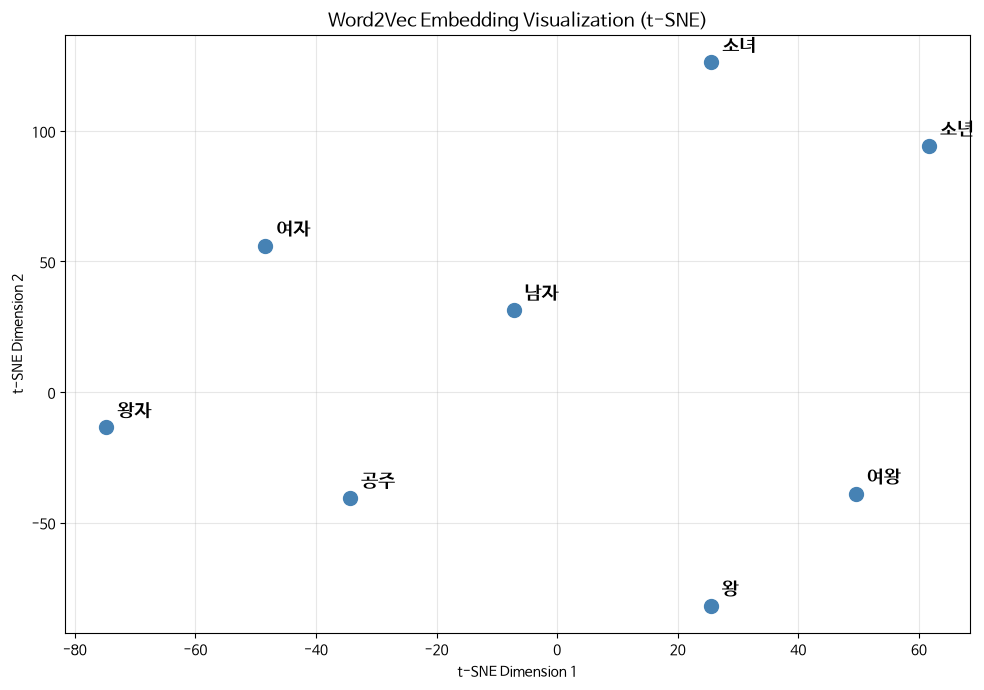


→ 의미적으로 유사한 단어들이 가까이 군집되는 것을 확인할 수 있습니다.


In [24]:
# === t-SNE 시각화 ===
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 한글 폰트는 cell 4 의 setup_korean_font() 가 이미 설정함

# 시각화할 단어 선택
words = ["왕", "여왕", "왕자", "공주", "남자", "여자", "소년", "소녀"]
word_vectors = np.array([model.wv[w] for w in words])

# t-SNE로 2차원 축소
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(words)-1))
vectors_2d = tsne.fit_transform(word_vectors)

# 시각화
plt.figure(figsize=(10, 7))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='steelblue', s=100)

for i, word in enumerate(words):
    plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
                 fontsize=14, fontweight='bold',
                 xytext=(8, 8), textcoords='offset points')

plt.title('Word2Vec Embedding Visualization (t-SNE)', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n→ 의미적으로 유사한 단어들이 가까이 군집되는 것을 확인할 수 있습니다.")

---
## 4️⃣ 현대 임베딩: 문맥 기반 임베딩 (Contextual Embeddings)

### Word2Vec의 한계

Word2Vec은 각 단어에 **하나의 고정된 벡터**를 부여합니다. 하지만 다의어를 처리할 수 없습니다:

- "배"가 과일인지 탈것인지 구분 불가
- "눈"이 신체 부위인지 날씨인지 구분 불가

### 해결책: 문맥 기반 임베딩

| 모델 | 특징 | 연도 |
|------|------|------|
| **ELMo** | 양방향 LSTM으로 문맥 반영 | 2018 |
| **BERT** | Transformer의 양방향 인코더로 문맥 반영 | 2018 |
| **GPT** | Transformer의 디코더로 좌→우 문맥 반영 | 2018~ |

```
Word2Vec:  "배" → 항상 동일한 벡터 [0.2, -0.1, ...]

BERT:      "나는 배를 먹었다"  → "배" = [과일 의미 벡터]
           "배를 타고 갔다"    → "배" = [탈것 의미 벡터]
```

> **핵심**: 현대 LLM(GPT-4, Claude, LLaMA 등)은 모두 Transformer 기반의 **문맥 기반 임베딩**을 사용합니다.

In [14]:
# === BERT의 문맥 기반 임베딩 맛보기 ===
from transformers import AutoModel, AutoTokenizer
import torch

tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
model_bert = AutoModel.from_pretrained("bert-base-multilingual-cased")
model_bert.eval()

def get_word_embedding(sentence, target_word):
    """BERT로 특정 단어의 문맥 임베딩을 추출합니다."""
    inputs = tokenizer(sentence, return_tensors="pt")
    with torch.no_grad():
        outputs = model_bert(**inputs)
    
    # 토큰 확인
    tokens = tokenizer.tokenize(sentence)
    # 타겟 단어의 첫 번째 토큰 임베딩 반환 (+1은 [CLS] 토큰 때문)
    for i, token in enumerate(tokens):
        if target_word in token:
            return outputs.last_hidden_state[0, i+1, :].numpy()
    return outputs.last_hidden_state[0, 1, :].numpy()

# 같은 단어 "배"가 다른 문맥에서 다른 임베딩을 가짐
emb1 = get_word_embedding("나는 배를 먹었다", "배")
emb2 = get_word_embedding("배를 타고 바다로 갔다", "배")
emb3 = get_word_embedding("배가 너무 아프다", "배")
emb4 = get_word_embedding("배를 타면 항상 멀미가 나", "배")

# 코사인 유사도 계산
from numpy.linalg import norm
cos = lambda a, b: np.dot(a, b) / (norm(a) * norm(b))

print("=== BERT 문맥 임베딩: '배'의 다양한 의미 1 ===")
print(f"  '배를 먹었다' vs '배를 타고': {cos(emb1, emb2):.4f}")
print(f"  '배를 먹었다' vs '배가 아프다': {cos(emb1, emb3):.4f}")
print(f"  '배를 타고'   vs '배가 아프다': {cos(emb2, emb3):.4f}")
print("\n  → 같은 '배'이지만 문맥에 따라 다른 임베딩 값을 가집니다!")
print("")
print("=== BERT 문맥 임베딩: '배'의 다양한 의미 2 ===")
print(f"  '배를 타고'   vs '배를 타면': {cos(emb2, emb4):.4f}")
print("\n  → 같은 '배'의 문맥이 같으면 당연히 유사도 ~ 1!")


model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Could not set the permissions on the file '/workspace/.cache/huggingface/hub/models--bert-base-multilingual-cased/blobs/876f584f15ebf14887dec17539c114bb99a032e96b9e72507a51c41e205337fc.f50a327c.incomplete'. Error: [Errno 1] Operation not permitted: '/workspace/.cache/huggingface/hub/models--bert-base-multilingual-cased/blobs/876f584f15ebf14887dec17539c114bb99a032e96b9e72507a51c41e205337fc.f50a327c.incomplete'.
Continuing without setting permissions.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== BERT 문맥 임베딩: '배'의 다양한 의미 1 ===
  '배를 먹었다' vs '배를 타고': 0.7472
  '배를 먹었다' vs '배가 아프다': 0.7322
  '배를 타고'   vs '배가 아프다': 0.7176

  → 같은 '배'이지만 문맥에 따라 다른 임베딩 값을 가집니다!

=== BERT 문맥 임베딩: '배'의 다양한 의미 2 ===
  '배를 타고'   vs '배를 타면': 0.8699

  → 같은 '배'의 문맥이 같으면 당연히 유사도 ~ 1!


---
## 5️⃣ 실습: 한국어 텍스트 토큰화 + 임베딩 실습

한국어 텍스트를 직접 토큰화하고, Word2Vec 임베딩을 학습한 후 시각화하는 종합 실습입니다.

In [15]:
# === 실습용 한국어 텍스트 데이터 ===
korean_texts = [
    "인공지능은 기계가 인간의 지능을 모방하는 기술이다",
    "딥러닝은 인공 신경망을 활용한 기계 학습 방법이다",
    "자연어 처리는 컴퓨터가 인간의 언어를 이해하는 기술이다",
    "트랜스포머 모델은 어텐션 메커니즘을 사용한다",
    "대규모 언어 모델은 많은 데이터로 학습된다",
    "GPT는 생성형 사전 학습 트랜스포머이다",
    "BERT는 양방향 인코더 트랜스포머이다",
    "임베딩은 단어를 벡터 공간에 표현하는 방법이다",
    "토큰화는 텍스트를 작은 단위로 분리하는 과정이다",
    "어텐션은 입력의 중요한 부분에 집중하는 기법이다",
    "신경망은 뉴런으로 구성된 계산 모델이다",
    "기계 학습은 데이터에서 패턴을 학습하는 방법이다",
]

print(f"준비된 텍스트 수: {len(korean_texts)}")
for i, t in enumerate(korean_texts[:3]):
    print(f"  [{i}] {t}")
print("  ...")

준비된 텍스트 수: 12
  [0] 인공지능은 기계가 인간의 지능을 모방하는 기술이다
  [1] 딥러닝은 인공 신경망을 활용한 기계 학습 방법이다
  [2] 자연어 처리는 컴퓨터가 인간의 언어를 이해하는 기술이다
  ...


In [16]:
# === Step 1: 간단한 토큰화 (공백 기준) ===
tokenized_texts = [text.split() for text in korean_texts]

print("=== 공백 기준 토큰화 결과 ===")
for i, tokens in enumerate(tokenized_texts[:3]):
    print(f"  [{i}] {tokens}")

# 전체 어휘 확인
all_words = set(w for tokens in tokenized_texts for w in tokens)
print(f"\n전체 고유 단어 수: {len(all_words)}")

from collections import Counter
cnt = Counter(w for tokens in tokenized_texts for w in tokens)
hapax = sum(1 for c in cnt.values() if c == 1)
print(f"총 토큰 수: {sum(cnt.values())}개")
print(f"그중 딱 1번만 등장한 단어: {hapax}개 (전체 어휘의 {hapax / len(cnt) * 100:.0f}%)")

print("\n⚠️ 한국어는 교착어 — 조사·어미가 붙어 활용형마다 '다른 단어'가 됩니다:")
for stem in ["학습", "인공", "언어"]:
    print(f"   '{stem}' 계열 → {sorted(w for w in cnt if stem in w)}")

print("\n→ 셀 10에서 지적한 '단어 단위 토큰화의 한계'가 실제 데이터에서 재현된 것입니다.")
print("   어휘의 대부분이 1회 등장 = Word2Vec이 학습할 통계 자체가 없습니다.")

=== 공백 기준 토큰화 결과 ===
  [0] ['인공지능은', '기계가', '인간의', '지능을', '모방하는', '기술이다']
  [1] ['딥러닝은', '인공', '신경망을', '활용한', '기계', '학습', '방법이다']
  [2] ['자연어', '처리는', '컴퓨터가', '인간의', '언어를', '이해하는', '기술이다']

전체 고유 단어 수: 61
총 토큰 수: 69개
그중 딱 1번만 등장한 단어: 54개 (전체 어휘의 89%)

⚠️ 한국어는 교착어 — 조사·어미가 붙어 활용형마다 '다른 단어'가 됩니다:
   '학습' 계열 → ['학습', '학습된다', '학습은', '학습하는']
   '인공' 계열 → ['인공', '인공지능은']
   '언어' 계열 → ['언어', '언어를']

→ 셀 10에서 지적한 '단어 단위 토큰화의 한계'가 실제 데이터에서 재현된 것입니다.
   어휘의 대부분이 1회 등장 = Word2Vec이 학습할 통계 자체가 없습니다.


In [17]:
# === Step 2: Word2Vec 임베딩 학습 ===
model_ko = Word2Vec(
    tokenized_texts,
    vector_size=30,
    window=3,
    min_count=1,
    sg=1,
    epochs=2000,   # 너무 작으면 벡터가 초기값에 머물고, 너무 크면(5000+)
               #            과학습으로 군집이 와해됩니다 (셀 17 참고)
    seed=42,
    workers=1,     # 재현성
)

print("Word2Vec 학습 완료!")
print(f"어휘 크기: {len(model_ko.wv)}, 임베딩 차원: {model_ko.wv.vector_size}")

# 유사 단어 검색
print("\n=== '기술이다'와 유사한 단어 ===")
for word, score in model_ko.wv.most_similar("기술이다", topn=5):
    print(f"  {word}: {score:.4f}")

print("\n=== '트랜스포머이다'와 유사한 단어 ===")
for word, score in model_ko.wv.most_similar("트랜스포머이다", topn=5):
    print(f"  {word}: {score:.4f}")

print("\n👀 관찰 포인트")
print("   '트랜스포머이다' 결과(GPT는·BERT는·생성형·양방향)가 그럴듯해 보이지만")
print("   '의미가 비슷해서'가 아니라 '같은 문장에 있었기 때문'입니다 (window=3 안의 공기).")
print("   '기술이다' → '인간의' 같은 무의미한 결과가 그 증거입니다.")
print("   → 임베딩 품질은 코퍼스 규모가 좌우합니다. 12문장으로는 의미를 못 배웁니다.")

Word2Vec 학습 완료!
어휘 크기: 61, 임베딩 차원: 30

=== '기술이다'와 유사한 단어 ===
  인간의: 0.9933
  인공지능은: 0.9313
  모방하는: 0.9297
  지능을: 0.9216
  기계가: 0.9214

=== '트랜스포머이다'와 유사한 단어 ===
  GPT는: 0.9301
  생성형: 0.9300
  인코더: 0.9272
  BERT는: 0.9269
  사전: 0.9268

👀 관찰 포인트
   '트랜스포머이다' 결과(GPT는·BERT는·생성형·양방향)가 그럴듯해 보이지만
   '의미가 비슷해서'가 아니라 '같은 문장에 있었기 때문'입니다 (window=3 안의 공기).
   '기술이다' → '인간의' 같은 무의미한 결과가 그 증거입니다.
   → 임베딩 품질은 코퍼스 규모가 좌우합니다. 12문장으로는 의미를 못 배웁니다.


findfont: Failed to find font weight bold for NanumBarunGothic, now using 600.


⚠️ 어휘에 없어 시각화에서 빠진 단어: ['학습한다']
   코퍼스에 있는 '학습' 활용형: ['학습', '학습하는', '학습은', '학습된다']
   → 공백 토큰화에서는 '학습한다'와 '학습된다'가 완전히 다른 단어입니다.



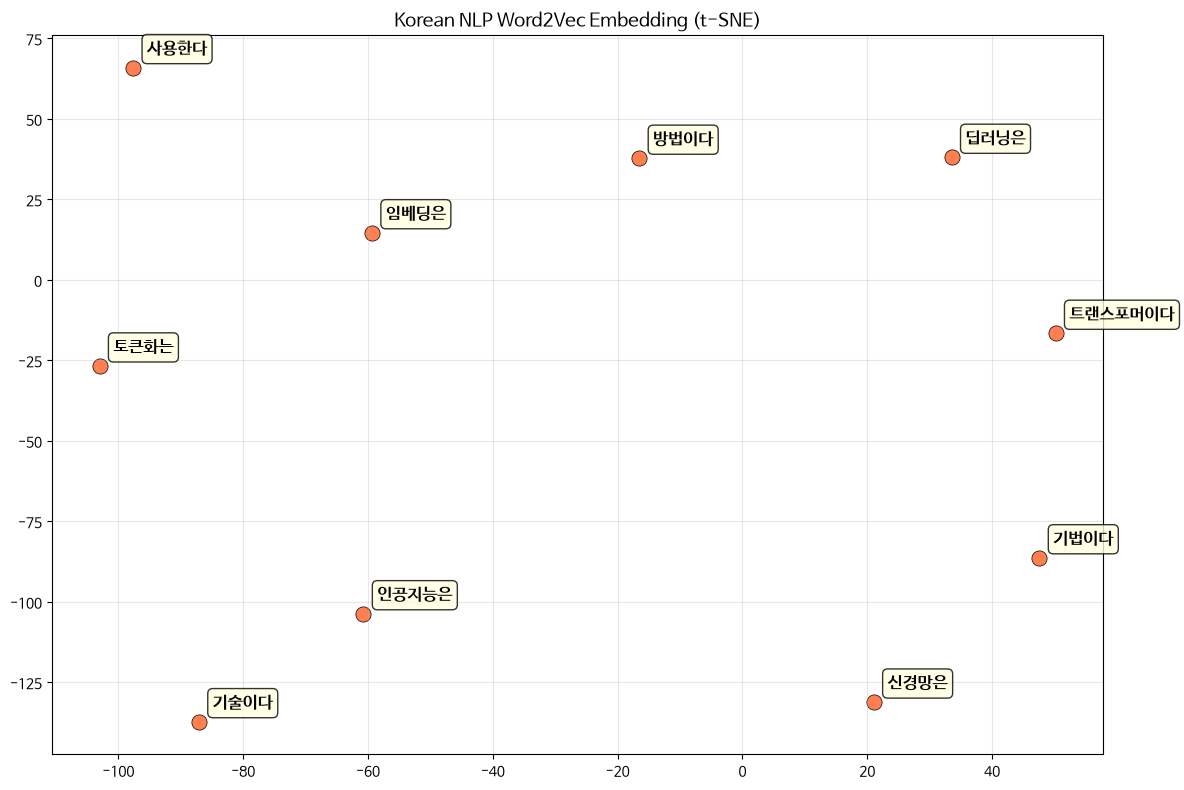

→ 의미적으로 유사한 단어들이 가까이 모이는 것을 관찰해 보세요.


In [25]:
# === Step 3: 임베딩 시각화 ===
# 시각화할 단어 선택 (주요 키워드)
target_words = [
    "인공지능은", "딥러닝은", "트랜스포머이다",
    "임베딩은", "토큰화는", "신경망은",
    "기술이다", "방법이다", "기법이다",
    "학습한다", "사용한다",
]

# 모델에 있는 단어만 필터링 (빠진 단어는 조용히 버리지 말고 드러냅니다)
missing = [w for w in target_words if w not in model_ko.wv]
target_words = [w for w in target_words if w in model_ko.wv]
if missing:
    print(f"⚠️ 어휘에 없어 시각화에서 빠진 단어: {missing}")
    print(f"   코퍼스에 있는 '학습' 활용형: "
          f"{[w for w in model_ko.wv.index_to_key if '학습' in w]}")
    print("   → 공백 토큰화에서는 '학습한다'와 '학습된다'가 완전히 다른 단어입니다.\n")
vectors = np.array([model_ko.wv[w] for w in target_words])

# t-SNE 차원 축소
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(target_words)-1))
vectors_2d = tsne.fit_transform(vectors)

# 시각화
plt.figure(figsize=(12, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='coral', s=120, edgecolors='black', linewidths=0.5)

for i, word in enumerate(target_words):
    plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
                 fontsize=12, fontweight='bold',
                 xytext=(10, 10), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.title('Korean NLP Word2Vec Embedding (t-SNE)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ 의미적으로 유사한 단어들이 가까이 모이는 것을 관찰해 보세요.")

In [19]:
# === Step 4: 토크나이저 비교 실험 ===
from transformers import AutoTokenizer

test_text = "대규모 언어 모델은 자연어 처리의 핵심 기술이다"

tokenizers_info = [
    ("GPT-2 (영어 전용)",          "gpt2"),
    ("BERT (Multilingual)",       "bert-base-multilingual-cased"),
    ("Qwen2.5 (7~12강 실습 모델)",  "Qwen/Qwen2.5-1.5B-Instruct"),
    ("KLUE-BERT (한국어 특화)",     "klue/bert-base"),
]

print(f"입력 텍스트: \"{test_text}\"  (공백 기준 8어절 / 26글자)\n")
print(f"{'Tokenizer':<24} {'토큰 수':>6}   앞부분 7개")
print("-" * 88)

counts = {}
for name, model_name in tokenizers_info:
    tok = AutoTokenizer.from_pretrained(model_name)
    tokens = tok.tokenize(test_text)
    counts[name] = len(tokens)
    print(f"{name:<24} {len(tokens):>6}   {tokens[:7]}")

n_gpt2 = counts["GPT-2 (영어 전용)"]
n_klue = counts["KLUE-BERT (한국어 특화)"]

print(f"\n→ GPT-2 {n_gpt2}개: 'ë', 'Į', 'Ģ' 는 글자가 아니라 UTF-8 '바이트 조각'입니다.")
print(f"   셀 8의 '한글 1글자 = 3바이트' 가 여기서 그대로 드러납니다 (26글자 → {n_gpt2}토큰).")
print(f"   영어 전용 토크나이저는 한국어를 '모른다'고 보는 편이 정확합니다.")
print(f"→ KLUE-BERT {n_klue}개: '언어', '모델', '##규모' 처럼 의미 단위로 자릅니다.")
print(f"→ 같은 문장이 {n_gpt2}토큰 vs {n_klue}토큰 — {n_gpt2 / n_klue:.1f}배 차이")
print("   토큰 수 = 컨텍스트 소모 = API 비용. 03강 컨텍스트 길이와 직결됩니다.")

입력 텍스트: "대규모 언어 모델은 자연어 처리의 핵심 기술이다"  (공백 기준 8어절 / 26글자)

Tokenizer                  토큰 수   앞부분 7개
----------------------------------------------------------------------------------------
GPT-2 (영어 전용)                57   ['ë', 'Į', 'Ģ', 'ê', '·', 'ľ', 'ë']
BERT (Multilingual)          18   ['대', '##규', '##모', '언', '##어', '모', '##델']


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

Could not set the permissions on the file '/workspace/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/blobs/f81ead14ab072d65a07817f83a3ee0e5a1890d10.79f86fd6.incomplete'. Error: [Errno 1] Operation not permitted: '/workspace/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/blobs/f81ead14ab072d65a07817f83a3ee0e5a1890d10.79f86fd6.incomplete'.
Continuing without setting permissions.


tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

Could not set the permissions on the file '/workspace/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/blobs/07bfe0640cb5a0037f9322287fbfc682806cf672.4351763a.incomplete'. Error: [Errno 1] Operation not permitted: '/workspace/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/blobs/07bfe0640cb5a0037f9322287fbfc682806cf672.4351763a.incomplete'.
Continuing without setting permissions.


...

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

Could not set the permissions on the file '/workspace/.cache/huggingface/hub/models--klue--bert-base/blobs/1732a7ece78ed59e6176c7833fc10191b99a1f29.b6d4c22d.incomplete'. Error: [Errno 1] Operation not permitted: '/workspace/.cache/huggingface/hub/models--klue--bert-base/blobs/1732a7ece78ed59e6176c7833fc10191b99a1f29.b6d4c22d.incomplete'.
Continuing without setting permissions.


special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Could not set the permissions on the file '/workspace/.cache/huggingface/hub/models--klue--bert-base/blobs/cf6870d6e6b8c07e15fffa270fa7101137ba8c5b.16099ce2.incomplete'. Error: [Errno 1] Operation not permitted: '/workspace/.cache/huggingface/hub/models--klue--bert-base/blobs/cf6870d6e6b8c07e15fffa270fa7101137ba8c5b.16099ce2.incomplete'.
Continuing without setting permissions.


KLUE-BERT (한국어 특화)           12   ['대', '##규모', '언어', '모델', '##은', '자연', '##어']

→ GPT-2 57개: 'ë', 'Į', 'Ģ' 는 글자가 아니라 UTF-8 '바이트 조각'입니다.
   셀 8의 '한글 1글자 = 3바이트' 가 여기서 그대로 드러납니다 (26글자 → 57토큰).
   영어 전용 토크나이저는 한국어를 '모른다'고 보는 편이 정확합니다.
→ KLUE-BERT 12개: '언어', '모델', '##규모' 처럼 의미 단위로 자릅니다.
→ 같은 문장이 57토큰 vs 12토큰 — 4.8배 차이
   토큰 수 = 컨텍스트 소모 = API 비용. 03강 컨텍스트 길이와 직결됩니다.


---

## 4️⃣ Word2Vec → KoSimCSE: 한국어 임베딩의 진화

Word2Vec 은 **단어** 단위로 학습 → 단순 의미 관계는 잡지만 **문맥**·**문장 의미**에는 약함.
**KoSimCSE-roberta** 는 KLUE-RoBERTa 위에 **SimCSE** (대조 학습) 를 한국어로 적용해
«문장 수준 의미 임베딩» 을 만든다.

| 방식 | 단위 | 학습 신호 | 한국어 특화 | 권장 사용처 |
|---|---|---|---|---|
| Word2Vec | 단어 | 주변 단어 예측 (CBOW/SG) | 데이터에 의존 | 단어 유사도·시각화 |
| Multilingual ST | 문장 | NLI 등 다국어 | △ (영어 위주) | 다국어 검색 |
| **KoSimCSE-roberta** | 문장 | 한국어 SimCSE + NLI | ✅ 한국어 최적화 | **한국어 RAG·검색** |

→ 같은 단어 셋으로 두 임베딩의 **코사인 유사도**·**t-SNE 클러스터링** 을 비교한다.


In [20]:
# KoSimCSE-roberta 로드 (최초 1회 ~430MB 다운로드)
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

KO_MODEL_ID = "BM-K/KoSimCSE-roberta-multitask"
ko_model = SentenceTransformer(KO_MODEL_ID)
print(f"✅ KoSimCSE 로드 완료 — 차원: {ko_model.get_embedding_dimension()}")

# 같은 단어들로 임베딩 비교 (cell 17 의 Word2Vec `ko_w2v` 와 동일 어휘 셋)
#   ※ cell 26 의 `model_ko` 는 AI 용어 코퍼스라 이 단어들과 겹치지 않습니다 — 이름이 비슷하니 주의
compare_words = ["왕", "여왕", "왕자", "공주", "남자", "여자", "소년", "소녀"]
ko_embeddings = ko_model.encode(compare_words, normalize_embeddings=True)
print(f"임베딩 shape: {ko_embeddings.shape}")


config.json:   0%|          | 0.00/764 [00:00<?, ?B/s]

Could not set the permissions on the file '/workspace/.cache/huggingface/hub/models--BM-K--KoSimCSE-roberta-multitask/blobs/b8c89ddc79eeaafb64a4ecd7f1f9c02f634d412a.6797497f.incomplete'. Error: [Errno 1] Operation not permitted: '/workspace/.cache/huggingface/hub/models--BM-K--KoSimCSE-roberta-multitask/blobs/b8c89ddc79eeaafb64a4ecd7f1f9c02f634d412a.6797497f.incomplete'.
Continuing without setting permissions.


model.safetensors: reconstructing file:   0%|          |  0.00B /  442MB            

model.safetensors: downloading bytes:           |  0.00B            

Could not set the permissions on the file '/workspace/.cache/huggingface/hub/models--BM-K--KoSimCSE-roberta-multitask/blobs/23b6f3fc26a30c241ff3036d5d0cf4b03147a380be2075869ee2a83ab66ae6a2.58bf81ba.incomplete'. Error: [Errno 1] Operation not permitted: '/workspace/.cache/huggingface/hub/models--BM-K--KoSimCSE-roberta-multitask/blobs/23b6f3fc26a30c241ff3036d5d0cf4b03147a380be2075869ee2a83ab66ae6a2.58bf81ba.incomplete'.
Continuing without setting permissions.


...

tokenizer.json:   0%|          | 0.00/752k [00:00<?, ?B/s]

Could not set the permissions on the file '/workspace/.cache/huggingface/hub/models--BM-K--KoSimCSE-roberta-multitask/blobs/d5843bc5b1306b80af3f6799607cfae7720e37a2.f93ec040.incomplete'. Error: [Errno 1] Operation not permitted: '/workspace/.cache/huggingface/hub/models--BM-K--KoSimCSE-roberta-multitask/blobs/d5843bc5b1306b80af3f6799607cfae7720e37a2.f93ec040.incomplete'.
Continuing without setting permissions.


special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

Could not set the permissions on the file '/workspace/.cache/huggingface/hub/models--BM-K--KoSimCSE-roberta-multitask/blobs/4d9e49690449efe416b116fa6153b094dc818020.6a975940.incomplete'. Error: [Errno 1] Operation not permitted: '/workspace/.cache/huggingface/hub/models--BM-K--KoSimCSE-roberta-multitask/blobs/4d9e49690449efe416b116fa6153b094dc818020.6a975940.incomplete'.
Continuing without setting permissions.


✅ KoSimCSE 로드 완료 — 차원: 768
임베딩 shape: (8, 768)


In [21]:
# Word2Vec vs KoSimCSE — 같은 단어 쌍의 코사인 유사도 비교

pairs = [
    ("왕", "여왕",   "성별 쌍"),
    ("남자", "여자", "성별 쌍"),
    ("소년", "소녀", "성별 쌍"),
    ("왕", "왕자",   "신분 관계"),
    ("여왕", "공주", "신분 관계"),
    ("왕", "남자",   "성별 추상화"),
    ("왕자", "소년", "나이 관계"),
]

print(f"{'단어 쌍':<14} {'Word2Vec':>10} {'KoSimCSE':>10}   설명")
print("─" * 70)
for a, b, desc in pairs:
    # Word2Vec — cell 17 에서 학습한 ko_w2v 사용 (gensim Word2Vec)
    try:
        w2v_sim = float(cosine_similarity(
            [ko_w2v.wv[a]], [ko_w2v.wv[b]]
        )[0, 0])
        w2v_str = f"{w2v_sim:>10.3f}"
    except (NameError, KeyError):
        w2v_str = f"{'N/A':>10}"
    # KoSimCSE
    ks_sim = float(cosine_similarity(
        [ko_embeddings[compare_words.index(a)]],
        [ko_embeddings[compare_words.index(b)]]
    )[0, 0])
    print(f"({a:>3}, {b:<3})    {w2v_str} {ks_sim:>10.3f}   {desc}")

print()
print("👀 관찰 포인트 — 두 모델의 «의미 분리 전략» 비교:")
print("  • Word2Vec    : 작은 코퍼스 + 단어 단위 → 유사도 변동 큼")
print("  • KoSimCSE    : 큰 코퍼스 + 문장 단위 SimCSE 학습")
print("     ─ '왕·여왕·왕자·공주' 가 강하게 묶임 (왕족 클러스터)")
print("     ─ '남자·여자·소년·소녀' 도 별도 클러스터 형성")
print("     ─ 흥미롭게도 '왕↔남자' 보다 '왕↔왕자' 가 더 가까움")
print("       → 문장 의미 기반이라 \"같은 카테고리\" 가 \"같은 성별\" 보다 우선")
print()
print("  💡 임베딩 모델마다 «의미를 묶는 기준» 이 다르다 — RAG·검색에 쓸 때")
print("     자기 도메인에서 어떤 클러스터가 나오는지 먼저 확인할 것")


단어 쌍             Word2Vec   KoSimCSE   설명
──────────────────────────────────────────────────────────────────────
(  왕, 여왕 )         0.980      0.438   성별 쌍
( 남자, 여자 )         0.977     -0.262   성별 쌍
( 소년, 소녀 )         0.968     -0.023   성별 쌍
(  왕, 왕자 )         0.676      0.597   신분 관계
( 여왕, 공주 )         0.673      0.657   신분 관계
(  왕, 남자 )         0.488      0.285   성별 추상화
( 왕자, 소년 )         0.354      0.401   나이 관계

👀 관찰 포인트 — 두 모델의 «의미 분리 전략» 비교:
  • Word2Vec    : 작은 코퍼스 + 단어 단위 → 유사도 변동 큼
  • KoSimCSE    : 큰 코퍼스 + 문장 단위 SimCSE 학습
     ─ '왕·여왕·왕자·공주' 가 강하게 묶임 (왕족 클러스터)
     ─ '남자·여자·소년·소녀' 도 별도 클러스터 형성
     ─ 흥미롭게도 '왕↔남자' 보다 '왕↔왕자' 가 더 가까움
       → 문장 의미 기반이라 "같은 카테고리" 가 "같은 성별" 보다 우선

  💡 임베딩 모델마다 «의미를 묶는 기준» 이 다르다 — RAG·검색에 쓸 때
     자기 도메인에서 어떤 클러스터가 나오는지 먼저 확인할 것


/tmp/ipykernel_7870/3961104416.py:32: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7870/3961104416.py:32: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7870/3961104416.py:32: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7870/3961104416.py:32: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7870/3961104416.py:32: UserWarning: Glyph 54140 (\N{HANGUL SYLLABLE PEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7870/3961104416.py:32: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7870/3961104416.py:32: UserWarning: Glyph 50773 (\N{HANGUL SYLLABLE WANG}) missing from font(s) DejaVu Sans.
  plt.tight_la

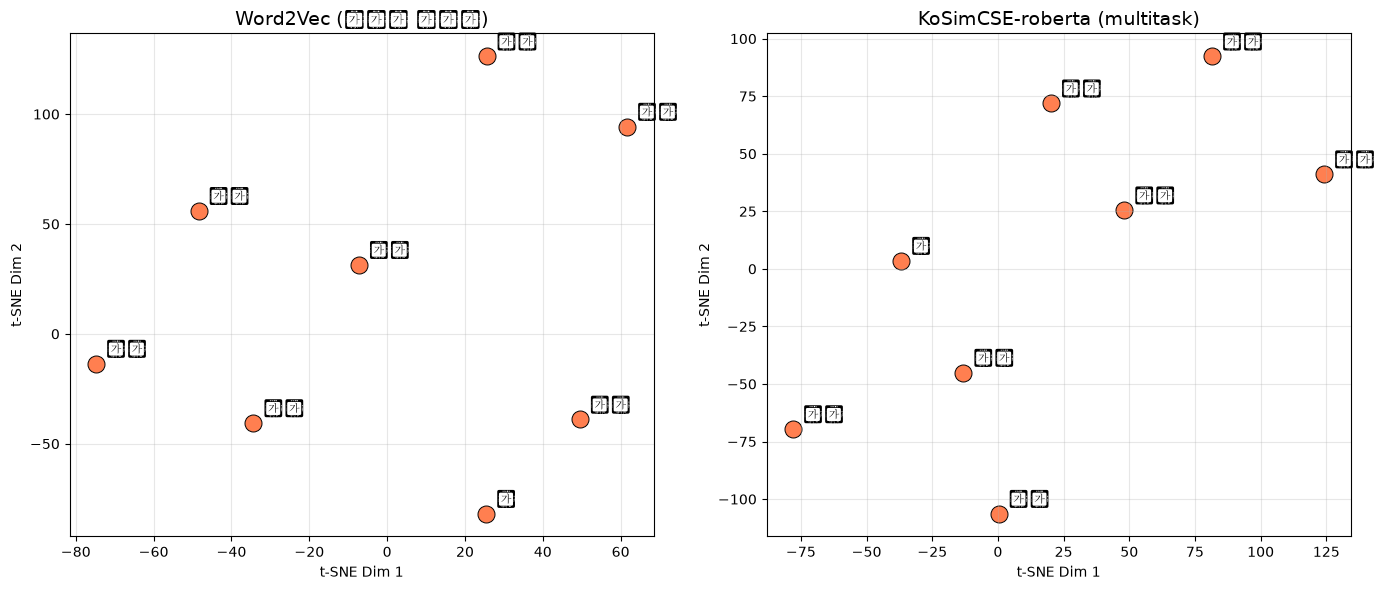

✅ 두 임베딩의 t-SNE 시각화를 비교했습니다.
   KoSimCSE 가 성별·신분 클러스터를 더 명확히 분리하는 경향을 보입니다.


In [22]:
# t-SNE 시각화 — Word2Vec vs KoSimCSE 나란히 (한글 폰트는 cell 4 에서 설정됨)
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

datasets = [
    ("Word2Vec (한국어 코퍼스)",
     np.array([ko_w2v.wv[w] for w in compare_words]) if 'ko_w2v' in dir() else None),
    ("KoSimCSE-roberta (multitask)", ko_embeddings),
]

for ax, (title, embs) in zip(axes, datasets):
    if embs is None:
        ax.text(0.5, 0.5, "Word2Vec 모델이\n로드되지 않음",
                ha="center", va="center", transform=ax.transAxes, fontsize=14)
        ax.set_title(title, fontsize=14)
        continue
    tsne = TSNE(n_components=2, random_state=42,
                perplexity=min(5, len(compare_words)-1), init="pca")
    vec_2d = tsne.fit_transform(embs)
    ax.scatter(vec_2d[:, 0], vec_2d[:, 1], c="coral", s=150,
               edgecolors="black", linewidth=0.7)
    for i, w in enumerate(compare_words):
        ax.annotate(w, vec_2d[i], fontsize=13,
                    xytext=(7, 7), textcoords="offset points")
    ax.set_title(title, fontsize=14)
    ax.grid(alpha=0.3)
    ax.set_xlabel("t-SNE Dim 1")
    ax.set_ylabel("t-SNE Dim 2")

plt.tight_layout()
plt.savefig("word2vec_vs_kosimcse.png", dpi=100, bbox_inches="tight")
plt.show()
print("✅ 두 임베딩의 t-SNE 시각화를 비교했습니다.")
print("   KoSimCSE 가 성별·신분 클러스터를 더 명확히 분리하는 경향을 보입니다.")


---
## 요약

| 개념 | 핵심 내용 |
|------|----------|
| **인코딩** | 문자 → 숫자 변환 (ASCII → Unicode/UTF-8) |
| **토큰화** | 텍스트 → 토큰 분리 (BPE, WordPiece, SentencePiece) |
| **Word2Vec** | 단어 → 밀집 벡터 (의미 유사도 표현 가능) |
| **문맥 임베딩** | 같은 단어도 문맥에 따라 다른 벡터 (BERT, GPT) |

### 다음 세션 예고

- 🔜 **Session 02**: 트랜스포머 아키텍처 - Attention, BERT, GPT 구조 비교

**© Copyright AIDENTIFY. All rights reserved.**